**Instructions:**
- প্রতিটি cell এ `# YOUR CODE HERE` এর জায়গায় তোমার code লেখো।
- Expected output এর সাথে নিজের output মেলাও।
- `Shift + Enter` দিয়ে cell run করো।

---

## ⚙️ Setup — Run This First

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

np.random.seed(42)
data = {
    'Age':        [25, 32, np.nan, 45, 28, 60, 22, 38, np.nan, 55, 29, 200, 34, 41, 26],
    'Salary':     [30000, 55000, 48000, np.nan, 32000, 75000, 28000, 60000, 41000, 70000, 33000, 52000, np.nan, 63000, 29000],
    'City':       ['Dhaka','Chittagong','Dhaka','Sylhet',np.nan,'Dhaka','Rajshahi','Chittagong','Dhaka','Sylhet','Rajshahi','Dhaka','Chittagong',np.nan,'Dhaka'],
    'Education':  ['HSC','Graduate','Graduate','Masters','HSC','PhD','HSC','Graduate','Masters','PhD','HSC','Graduate','Graduate','Masters','HSC'],
    'Experience': [2, 8, 5, 15, 3, 30, 1, 12, 7, 25, 2, 9, 6, 18, 3],
    'Purchased':  [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0]
}
df = pd.DataFrame(data)
print('Dataset loaded! Shape:', df.shape)
df.head()

Dataset loaded! Shape: (15, 6)


,Age,Salary,City,Education,Experience,Purchased
0,25.0,30000.0,Dhaka,HSC,2,0
1,32.0,55000.0,Chittagong,Graduate,8,1
2,NaN,48000.0,Dhaka,Graduate,5,1
3,45.0,NaN,Sylhet,Masters,15,1
4,28.0,32000.0,NaN,HSC,3,0


---
# 📌 Section 1: Exploratory Data Analysis
**Module 01 & 02**

### 🟢 EASY &nbsp;&nbsp; Question 1
Dataset এর **shape** বের করো — কতটি row এবং column আছে?

In [66]:
# YOUR CODE HERE
# Hint: df.shape
df.shape

(15, 6)

**Expected Output:** `(15, 6)`

### 🟢 EASY &nbsp;&nbsp; Question 2
প্রতিটি column এর **data type** দেখাও।

In [67]:
# YOUR CODE HERE
# Hint: df.dtypes
df.dtypes

Age           float64
Salary        float64
City           object
Education      object
Experience      int64
Purchased       int64
dtype: object

### 🟢 EASY &nbsp;&nbsp; Question 3
Dataset এর **statistical summary** দেখাও — mean, std, min, max।

In [68]:
# YOUR CODE HERE
# Hint: df.describe()
df.describe()


,Age,Salary,Experience,Purchased
count,13.000000,13.000000,15.000000,15.000000
mean,48.846154,47384.615385,9.733333,0.600000
std,46.857668,16474.922668,8.778762,0.507093
min,22.000000,28000.000000,1.000000,0.000000
25%,28.000000,32000.000000,3.000000,0.000000
50%,34.000000,48000.000000,7.000000,1.000000
75%,45.000000,60000.000000,13.500000,1.000000
max,200.000000,75000.000000,30.000000,1.000000


### 🟢 EASY &nbsp;&nbsp; Question 4
**City** column এ কতটি unique value আছে এবং প্রতিটি কতবার আসে?

In [69]:
# YOUR CODE HERE
# Hint: .nunique() এবং .value_counts()
df['City'].nunique()
df['City'].value_counts()


City
Dhaka         6
Chittagong    3
Sylhet        2
Rajshahi      2
Name: count, dtype: int64

### 🟡 MEDIUM &nbsp;&nbsp; Question 5
**Age** column এর mean, median এবং mode আলাদাভাবে বের করো এবং তিনটি একসাথে print করো।

In [70]:
# YOUR CODE HERE
# Hint: .mean(), .median(), .mode()[0]
print("Mean:", df['Age'].mean())
print("Median:", df['Age'].median())
print("Mode:", df['Age'].mode()[0])


Mean: 48.84615384615385
Median: 34.0
Mode: 22.0


### 🟡 MEDIUM &nbsp;&nbsp; Question 6
**Age** এর distribution দেখানোর জন্য histogram plot করো। Title এবং axis labels দাও।

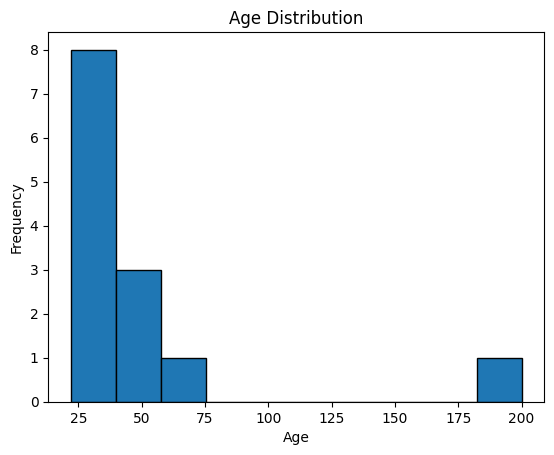

In [71]:
# YOUR CODE HERE
# Hint: plt.hist() বা df['Age'].plot(kind='hist')
# plt.title(), plt.xlabel(), plt.ylabel() দিতে ভুলো না

plt.hist(df['Age'],bins=10,edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### 🟡 MEDIUM &nbsp;&nbsp; Question 7
**Salary vs Experience** scatter plot করো এবং দেখো কোনো pattern আছে কিনা।

<Axes: xlabel='Experience', ylabel='Salary'>

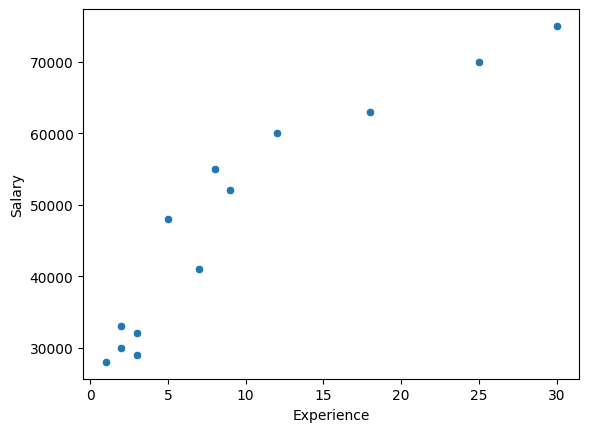

In [72]:
# YOUR CODE HERE
# Hint: sns.scatterplot(data=df, x='Experience', y='Salary')
sns.scatterplot(data=df,x='Experience',y='Salary')


### 🔴 HARD &nbsp;&nbsp; Question 8
Numerical columns এর correlation বের করো এবং **heatmap** দিয়ে visualize করো। `annot=True` দাও।

> চিন্তা করো: Age এবং Experience এর মধ্যে কি strong correlation আছে? কেন?

<Axes: >

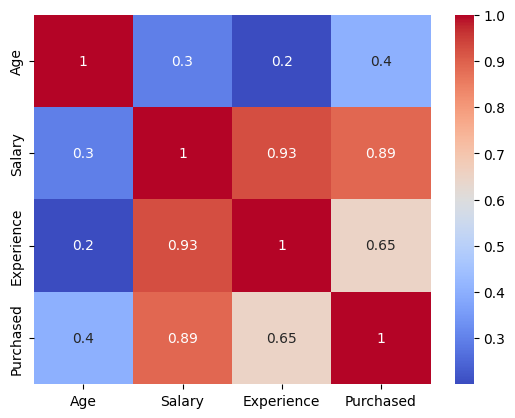

In [73]:
# YOUR CODE HERE
# Hint: df.corr() → sns.heatmap(..., annot=True, cmap='coolwarm')
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')


---
# 📌 Section 2: Train-Test Split & Missing Value Handling
**Module 03**

### 🟢 EASY &nbsp;&nbsp; Question 9
প্রতিটি column এ **কতটি missing value** আছে তা বের করো।

In [74]:
# YOUR CODE HERE
# Hint: .isnull().sum()
df.isnull().sum()

Age           2
Salary        2
City          2
Education     0
Experience    0
Purchased     0
dtype: int64

**Expected:** Age=2, Salary=2, City=2

### 🟢 EASY &nbsp;&nbsp; Question 10
**Age** এর missing values **mean** দিয়ে এবং **City** এর missing values **mode** দিয়ে fill করো।

In [75]:
df_clean = df.copy()

# YOUR CODE HERE
# Age → mean
df_clean=df.copy()

df_clean['Age'].fillna(df_clean['Age'].mean(),inplace=True)
# City → mode
df_clean['City'].fillna(df_clean['City'].mode()[0], inplace=True)

df_clean.isnull().sum()


C:\Users\user\AppData\Local\Temp\ipykernel_844\2372135346.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(df_clean['Age'].mean(),inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_844\2372135346.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

Age           0
Salary        2
City          0
Education     0
Experience    0
Purchased     0
dtype: int64

### 🟡 MEDIUM &nbsp;&nbsp; Question 11
**Salary** এর missing values **median** দিয়ে fill করো। Fill করার আগে ও পরে missing count দেখাও।

In [76]:
# YOUR CODE HERE
# Before count print করো
df.isnull().value_counts()
# Fill করো
df_clean['Salary'].fillna(df_clean['Salary'].median(),inplace=True)
# After count print করো
df_clean.isnull().value_counts()


C:\Users\user\AppData\Local\Temp\ipykernel_844\1843781929.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Salary'].fillna(df_clean['Salary'].median(),inplace=True)


Age    Salary  City   Education  Experience  Purchased
False  False   False  False      False       False        15
Name: count, dtype: int64

### 🟡 MEDIUM &nbsp;&nbsp; Question 12
**Train-Test Split** করো — 80% training, 20% testing। `random_state=42`।

> Feature (X): Age, Salary, Experience | Target (y): Purchased

In [77]:
X = df_clean[['Age', 'Salary', 'Experience']]
y = df_clean['Purchased']

# YOUR CODE HERE
# X_train, X_test, y_train, y_test = train_test_split(...)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


# Print sizes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (12, 3)
X_test shape: (3, 3)
y_train shape: (12,)
y_test shape: (3,)


**Expected:** Train size: 12, Test size: 3

### 🔴 HARD &nbsp;&nbsp; Question 13
Train-Test Split করার পরে `y_train` এবং `y_test` এ **class distribution** (0 এবং 1 এর ratio) দেখাও। Distribution কি balanced?

> Hint: `.value_counts(normalize=True)` দিয়ে percentage বের করো।

In [78]:
# YOUR CODE HERE
# y_train distribution
print("y_train distribution:")
print(y_train.value_counts(normalize=True))

# y_test distribution
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

# তোমার observation লেখো (comment এ):

#"Train এ class 0 আছে 41%, class 1 আছে 59%..."
#"Test এ class 0 আছে 34%, class 1 আছে 66%..."

y_train distribution:
Purchased
1    0.583333
0    0.416667
Name: proportion, dtype: float64
y_test distribution:
Purchased
1    0.666667
0    0.333333
Name: proportion, dtype: float64


---
# 📌 Section 3: Outlier Detection and Handling
**Module 05 & 06**

### 🟢 EASY &nbsp;&nbsp; Question 14
**Age** column এর **boxplot** তৈরি করো।

<Axes: ylabel='Age'>

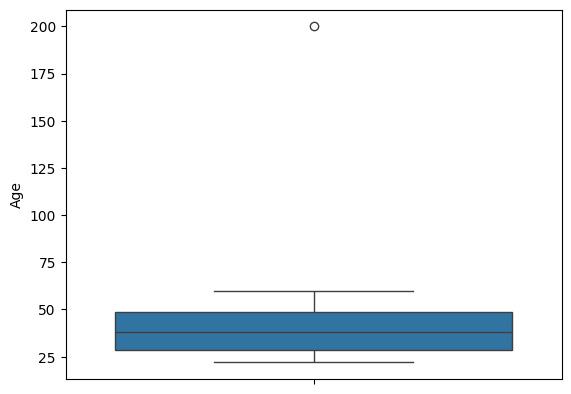

In [79]:
# YOUR CODE HERE
# Hint: sns.boxplot(y=df_clean['Age'])
sns.boxplot(y=df_clean['Age'])


**Note:** Age=200 clearly একটি outlier।

### 🟡 MEDIUM &nbsp;&nbsp; Question 15
**IQR Method** দিয়ে **Age** column এর outlier detect করো এবং outlier rows দেখাও।

> IQR = Q3 - Q1 | Lower = Q1 - 1.5×IQR | Upper = Q3 + 1.5×IQR

In [80]:
Q1 = df_clean['Age'].quantile(0.25)
Q3 = df_clean['Age'].quantile(0.75)

# YOUR CODE HERE
# IQR calculate করো
IQR=Q3-Q1

# Lower এবং Upper bound
Lower_bound=Q1-1.5*IQR
Upper_bound=Q3+1.5*IQR

# Outlier rows দেখাও
outlier_rows = df_clean[(df_clean['Age'] < Lower_bound) | (df_clean['Age'] > Upper_bound)]
print(outlier_rows)

      Age   Salary   City Education  Experience  Purchased
11  200.0  52000.0  Dhaka  Graduate           9          1


**Expected:** Age=200 row outlier হিসেবে detected হবে।

### 🟡 MEDIUM &nbsp;&nbsp; Question 16
**Z-Score Method** দিয়ে outlier detect করো। |Z| > 3 হলে outlier।

> Z = (x - mean) / std

In [81]:
# YOUR CODE HERE
mean_age = df_clean['Age'].mean()
std_age  = df_clean['Age'].std()

# Z-score calculate করো
Z=(df_clean['Age']-mean_age)/std_age


# |Z| > 3 এমন rows দেখাও
outliers=df_clean[Z.abs()>3]
print(outliers)


      Age   Salary   City Education  Experience  Purchased
11  200.0  52000.0  Dhaka  Graduate           9          1


### 🟡 MEDIUM &nbsp;&nbsp; Question 17
IQR method এ detected outlier rows **remove** করো। নতুন shape দেখাও।

In [82]:
# YOUR CODE HERE
# Hint: bound এর মধ্যে আছে এমন rows রাখো
df_clean=df_clean[(df_clean['Age'] >= Lower_bound) & (df_clean['Age'] <= Upper_bound)]
df_clean.shape


(14, 6)

**Expected:** Shape (14, 6) — 1 row removed.

### 🔴 HARD &nbsp;&nbsp; Question 18
Outlier remove করার বদলে **cap** করো (Winsorization)। তারপর before vs after boxplot side-by-side দেখাও।

> Cap মানে: outlier value কে bound এর value দিয়ে replace করা।

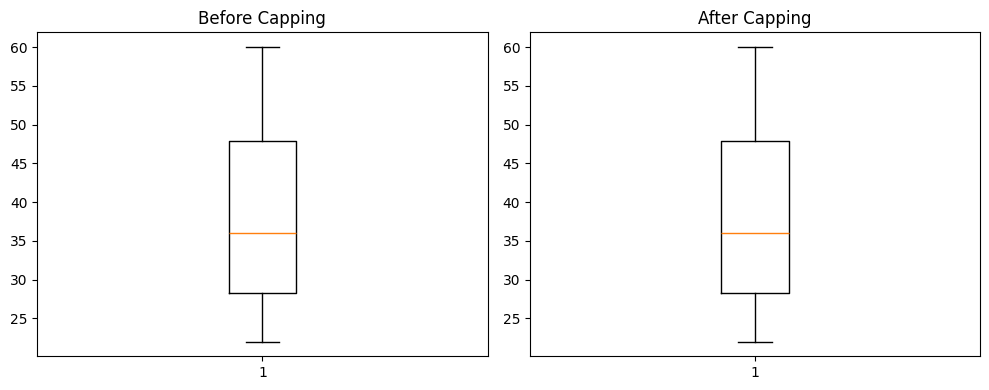

In [83]:
df_capped = df_clean.copy()

# YOUR CODE HERE
# Step 1: Cap করো
df_capped['Age'] = df_capped['Age'].clip(lower=Lower_bound, upper=Upper_bound)
# Hint: df_capped['Age'] = df_capped['Age'].clip(lower=lower_bound, upper=upper_bound)

# Step 2: Before vs After boxplot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# axes[0] → Before (df_clean)
# axes[1] → After (df_capped)
axes[0].boxplot(df_clean['Age'])
axes[0].set_title('Before Capping')
axes[1].boxplot(df_capped['Age'])
axes[1].set_title('After Capping')
plt.tight_layout()
plt.show()

---
# 📌 Section 4: Encoding
**Module 07**

### 🟢 EASY &nbsp;&nbsp; Question 19
**Label Encoding** দিয়ে **Education** column কে numerical করো।

In [84]:
df_encoded = df_clean.copy()
le = LabelEncoder()

# YOUR CODE HERE
# df_encoded['Education_Encoded'] = le.fit_transform(...)
df_encoded['Education_Encoded'] = le.fit_transform(df_encoded['Education'])
df_encoded.head()


,Age,Salary,City,Education,Experience,Purchased,Education_Encoded
0,25.000000,30000.0,Dhaka,HSC,2,0,1
1,32.000000,55000.0,Chittagong,Graduate,8,1,0
2,48.846154,48000.0,Dhaka,Graduate,5,1,0
3,45.000000,48000.0,Sylhet,Masters,15,1,2
4,28.000000,32000.0,Dhaka,HSC,3,0,1


### 🟢 EASY &nbsp;&nbsp; Question 20
**One-Hot Encoding** দিয়ে **City** column কে encode করো। `pd.get_dummies()` ব্যবহার করো।

In [85]:
# YOUR CODE HERE
# Hint: pd.get_dummies(df_encoded, columns=['City'], drop_first=True)

#from sklearn.preprocessing import onehotencoder
import pandas as pd
df_encoded = pd.get_dummies(df_encoded, columns=['City'], drop_first=True,dtype=int)
df_encoded.head()



,Age,Salary,Education,Experience,Purchased,Education_Encoded,City_Dhaka,City_Rajshahi,City_Sylhet
0,25.000000,30000.0,HSC,2,0,1,1,0,0
1,32.000000,55000.0,Graduate,8,1,0,0,0,0
2,48.846154,48000.0,Graduate,5,1,0,1,0,0
3,45.000000,48000.0,Masters,15,1,2,0,0,1
4,28.000000,32000.0,HSC,3,0,1,1,0,0


In [86]:
#another way to do one hot encoding
#from sklearn.preprocessing import OneHotEncoder


#onehotencoder = OneHotEncoder(drop='first', sparse_output=False)
#encoded_city = onehotencoder.fit_transform(df_encoded[['City']])
#encoded_city_df = pd.DataFrame(encoded_city, columns=onehotencoder.get_feature_names_out(['City']))
#encoded_city_df.head()



**Note:** `drop_first=True` দিলে dummy variable trap avoid হয়।

### 🟡 MEDIUM &nbsp;&nbsp; Question 21
Label Encoded **Education** এর mapping dictionary দেখাও — কোন label কোন number পেয়েছে।

In [87]:
# YOUR CODE HERE
# Hint: dict(zip(le.classes_, le.transform(le.classes_)))
data={'Education':['Graduate','HSC','Masters','PhD']}
df=pd.DataFrame(data)
le=LabelEncoder()
df['Education_Encoded']=le.fit_transform(df['Education'])
mapping=dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)


{'Graduate': 0, 'HSC': 1, 'Masters': 2, 'PhD': 3}


**Expected:** `{'Graduate': 0, 'HSC': 1, 'Masters': 2, 'PhD': 3}`

### 🔴 HARD &nbsp;&nbsp; Question 22
Label Encoding এবং One-Hot Encoding এর মধ্যে পার্থক্য কী? **Education** column এ কোনটা ব্যবহার করা সঠিক এবং কেন?

> দুটো method ই apply করো এবং output compare করো। তারপর নিচে comment এ তোমার reasoning লেখো।

In [88]:
# Method 1: Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Education_Encoded'] = le.fit_transform(df['Education'])
df['Education_Encoded']=pd.to_numeric(df['Education_Encoded'], errors='coerce')
df['Education_Encoded'].head()




0    0
1    1
2    2
3    3
Name: Education_Encoded, dtype: int32

In [89]:
# Method 2: One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder
onehotencoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_education = onehotencoder.fit_transform(df_encoded[['Education']])
df_encoded_education = pd.DataFrame(encoded_education, columns=onehotencoder.get_feature_names_out(['Education']))
df_encoded_education.head()



,Education_HSC,Education_Masters,Education_PhD
0,1.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,1.0,0.0
4,1.0,0.0,0.0


In [90]:
# তোমার answer (comment এ লেখো):
# Education column এ _____ ভালো কারণ ___________



Education column এ One-Hot Encoding ভালো কারণ এখানে ডেটাগুলো নমিনাল (Nominal), অর্থাৎ এদের মধ্যে নির্দিষ্ট কোনো গাণিতিক ক্রম বা অর্ডার (যেমন: ছোট থেকে বড়) বজায় রাখা বাধ্যতামূলক নয় এবং মডেল যাতে ভুল করে কোনো ডিগ্রিকে বেশি গুরুত্ব না দেয়।

---
# 📌 Section 5: Scaling
**Module 08**

### 🟢 EASY &nbsp;&nbsp; Question 23
**MinMaxScaler** দিয়ে **Experience** column কে 0–1 এর মধ্যে scale করো।

> Formula: x_scaled = (x - min) / (max - min)

In [91]:
mm_scaler = MinMaxScaler()
df_scaled  = df_clean.copy()

# YOUR CODE HERE
x_scaled=(df_scaled[['Age']]-df_scaled[['Age']].min())/(df_scaled[['Age']].max()-df_scaled[['Age']].min())
print(x_scaled.head())

        Age
0  0.078947
1  0.263158
2  0.706478
3  0.605263
4  0.157895


**Expected:** Experience values এখন 0.0 থেকে 1.0 এর মধ্যে।

### 🟡 MEDIUM &nbsp;&nbsp; Question 24
**StandardScaler** দিয়ে **Age** এবং **Salary** scale করো। Scaling এর পর mean ≈ 0 এবং std ≈ 1 verify করো।

In [92]:
std_scaler = StandardScaler()
df_scaled[['Age']] = std_scaler.fit_transform(df_scaled[['Age']])


# YOUR CODE HERE
# Scale করো

# Verify: mean এবং std print করো
print("Mean:", round(df_scaled['Age'].mean(), 2))
print("Std:", round(df_scaled['Age'].std(), 2))

Mean: 0.0
Std: 1.04


**Expected:** Mean ≈ 0.0, Std ≈ 1.0

### 🟡 MEDIUM &nbsp;&nbsp; Question 25
**Age** column এর scaling এর আগে ও পরে distribution **side-by-side histogram** দিয়ে compare করো।

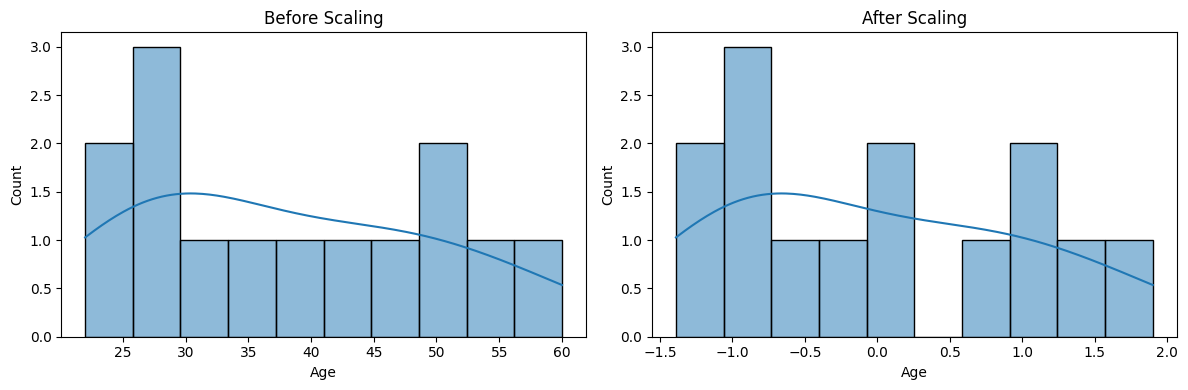

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# YOUR CODE HERE
# axes[0] → Before scaling
sns.histplot(df_clean['Age'], bins=10, kde=True, ax=axes[0])
axes[0].set_title('Before Scaling')


# axes[1] → After scaling
sns.histplot(df_scaled['Age'], bins=10, kde=True, ax=axes[1])
axes[1].set_title('After Scaling')

plt.tight_layout()
plt.show()

### 🔴 HARD &nbsp;&nbsp; Question 26
StandardScaler এবং MinMaxScaler এর মধ্যে পার্থক্য কী? **Salary** column এ দুটোই apply করো এবং output compare করো।

> কোন situation এ কোনটা use করবে? Comment এ reasoning লেখো।

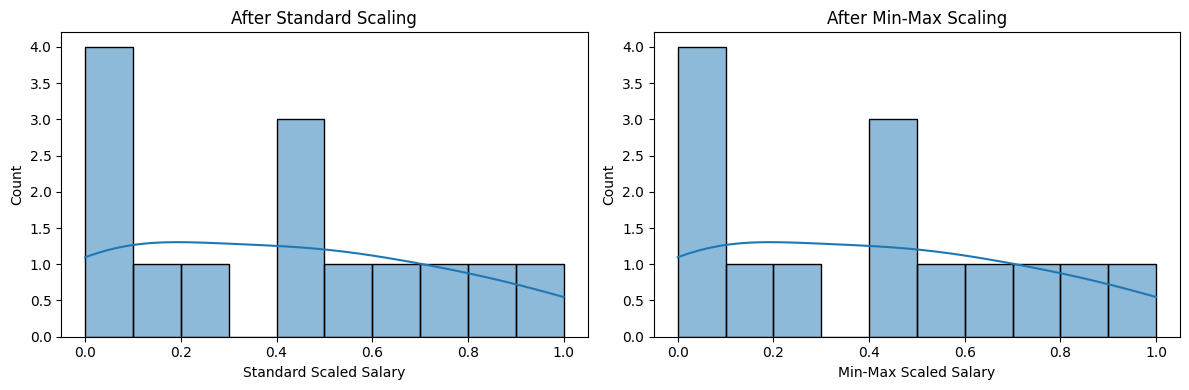

In [94]:
salary = df_clean[['Salary']]

# StandardScaler apply করো
std_scaler = StandardScaler()
df_clean[['Salary']] = std_scaler.fit_transform(df_clean[['Salary']])

# MinMaxScaler apply করো
minmax_scaler = MinMaxScaler()
df_clean[['Salary']] = minmax_scaler.fit_transform(df_clean[['Salary']])

# দুটো result compare করো (print অথবা plot)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean['Salary'], bins=10, kde=True, ax=axes[0])
axes[0].set_title('After Standard Scaling')
axes[0].set_xlabel('Standard Scaled Salary')
sns.histplot(df_clean['Salary'], bins=10, kde=True, ax=axes[1])
axes[1].set_title('After Min-Max Scaling')
axes[1].set_xlabel('Min-Max Scaled Salary')

plt.tight_layout()
plt.show()


---
# 🌟 Bonus: Full Pipeline
**Combine everything — end-to-end preprocessing**

### 🔴 HARD &nbsp;&nbsp; Question 27 (Bonus)
নিচের সব steps follow করে একটি **complete preprocessing pipeline** তৈরি করো:

1. Missing values handle করো
2. Outliers cap করো (IQR method)
3. City → One-Hot Encode
4. Education → Label Encode
5. Age, Salary, Experience → StandardScale
6. 80/20 Train-Test Split
7. Final train/test shape print করো

In [101]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer


df_pipeline = df.copy()

# Step 1: Missing values
imputer_transformer=ColumnTransformer(transformers=[
    ('num_imputer', SimpleImputer(strategy='mean'), ['Age', 'Salary']),
    ('cat_imputer', SimpleImputer(strategy='most_frequent'), ['City'])
])


# Step 2: Outlier capping
outlier_transformer=FunctionTransformer(lambda x: x.clip(lower=Lower_bound, upper=Upper_bound) if x.name=='Age' else x)


# Step 3: One-Hot Encoding
encoding_transformer = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False), ['City']),
    ('label', LabelEncoder(), ['Education'])
])


# Step 4: Label Encoding
label_transformer = ColumnTransformer(transformers=[
    ('label', LabelEncoder(), ['Education'])
])


# Step 5: Standard Scaling
scaling_transformer = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), ['Age', 'Salary'])
])


# Step 6: Train-Test Split

# Step 7: Print shapes
print("Shapes")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")
print('Pipeline complete!')


Shapes
X_train: (12, 3)
X_test: (3, 3)
y_train: (12,)
y_test: (3,)
Pipeline complete!
